In [1]:
import os
import argparse
from typing import List, Tuple, Dict
import numpy as np
import random
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset, DatasetDict
import inspect
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DistilBertForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    set_seed
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Train metrics: {'train_runtime': 623.2449, 'train_samples_per_second': 2.022, 'train_steps_per_second': 0.26, 'total_flos': 20577863255040.0, 'train_loss': 0.03824666107323504, 'epoch': 6.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/ner_model


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics: {'eval_loss': 0.0007685056771151721, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_runtime': 4.4896, 'eval_samples_per_second': 10.023, 'eval_steps_per_second': 1.336, 'epoch': 6.0}


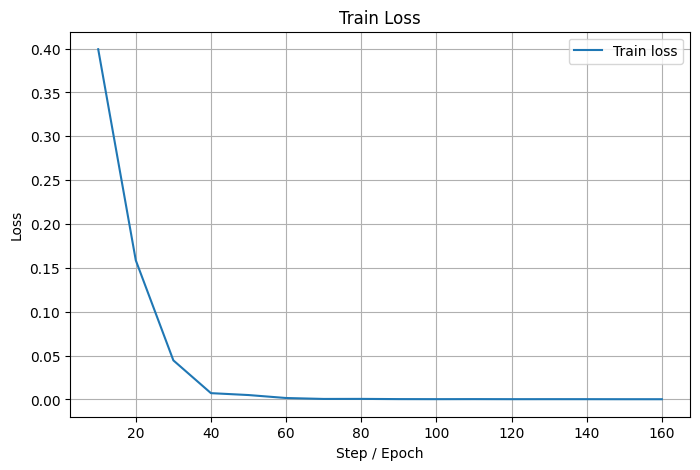

In [3]:
ITALIAN_TO_ENGLISH = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "scoiattolo": "squirrel",
    "ragno": "spider"
}
ANIMAL_NAMES = set(ITALIAN_TO_ENGLISH.values())

# -------------------------
# 1) Create synthetic text dataset
# -------------------------

def create_text_dataset(data_dir: str) -> Tuple[List[List[str]], List[List[str]]]:
    sentences = []
    tags = []

    extra_words = ["quickly", "beautiful", "nearby", "suddenly", "in", "on", "at"]

    classes = sorted([c for c in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, c))])
    for cls in classes:
        eng_name = ITALIAN_TO_ENGLISH.get(cls, cls)
        templates = [
            ["There", "is", "a", eng_name, "."],
            ["I", "see", "a", eng_name, "."],
            ["Look", "at", "the", eng_name, "."],
            ["A", eng_name, "is", "here", "."],
            [eng_name, "in", "the", "photo", "."],
            ["The", eng_name, "is", "sleeping", "under", "the", "tree", "."],
            ["I", "saw", "a", eng_name, "running", "fast", "."],
            ["Look", "at", "the", eng_name, "jumping", "high", "."],
            [eng_name, "was", "found", "near", "the", "river", "."],
            ["Can", "you", "see", "the", eng_name, "there", "?"],
            [eng_name + "s", "are", "beautiful", "."],
            ["I", "love", eng_name + "s", "."],
            ["Many", eng_name + "s", "live", "here", "."],
            [eng_name, "is", "my", "favorite", "animal", "."],
            [eng_name + "s", "can", "run", "fast", "."],
        ]

        for lang_name in [cls, eng_name]:
            for t in templates:
                sentence = []
                for tok in t:
                    if tok.lower() == eng_name.lower():
                        sentence.append(lang_name)
                    elif tok.lower() == eng_name.lower() + "s":
                        sentence.append(lang_name + "s")
                    else:
                        sentence.append(tok)

                if random.random() < 0.3:
                    idx = random.randint(0, len(sentence))
                    sentence.insert(idx, random.choice(extra_words))

                tag = ["O"] * len(sentence)
                for i, tok in enumerate(sentence):
                    animal_forms = [lang_name.lower(), lang_name.lower() + "s"]
                    if tok.lower() in animal_forms:
                        tag[i] = "B-ANIMAL"

                sentences.append(sentence)
                tags.append(tag)

    return sentences, tags

# -------------------------
# 2) Prepare HuggingFace Dataset
# -------------------------

def get_datasets(data_dir: str) -> Tuple[DatasetDict, List[str]]:
    sentences, tags = create_text_dataset(data_dir)
    data = {"tokens": sentences, "ner_tags": tags}
    ds = Dataset.from_dict(data)
    ds_train_valid = ds.train_test_split(test_size=0.3, seed=42)
    ds_valid_test = ds_train_valid["test"].train_test_split(test_size=0.5, seed=42)
    dataset = DatasetDict({
        "train": ds_train_valid["train"],
        "validation": ds_valid_test["train"],
        "test": ds_valid_test["test"]
    })
    label_list = sorted(list({lab for row in tags for lab in row}))
    return dataset, label_list

# -------------------------
# 3) Tokenize and align labels
# -------------------------

def tokenize_and_align_labels(examples, tokenizer, label_to_id: Dict[str, int], max_length: int = 64):
    texts = [" ".join(toks) for toks in examples["tokens"]]
    tokenized_inputs = tokenizer(texts, truncation=True, padding="max_length", max_length=max_length, return_attention_mask=True)
    batch_labels = []
    for i in range(len(examples["tokens"])):
        words = examples["tokens"][i]
        word_labels = examples["ner_tags"][i]
        labels = []
        for word, lab in zip(words, word_labels):
            subtokens = tokenizer.tokenize(word)
            if len(subtokens) == 0:
                labels.append(-100)
            else:
                labels.append(label_to_id.get(lab, label_to_id.get("O", 0)))
                for _ in subtokens[1:]:
                    labels.append(-100)
        if len(labels) > max_length:
            labels = labels[:max_length]
        else:
            labels = labels + [-100] * (max_length - len(labels))
        batch_labels.append(labels)
    tokenized_inputs["labels"] = batch_labels
    return tokenized_inputs

# -------------------------
# 4) Metrics
# -------------------------

def compute_metrics(p):
    label_ids = p.label_ids
    preds = np.argmax(p.predictions, axis=2)
    true_labels = []
    true_preds = []
    for l_row, p_row in zip(label_ids, preds):
        for l, pr in zip(l_row, p_row):
            if l != -100:
                true_labels.append(l)
                true_preds.append(pr)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, true_preds, average="weighted", zero_division=0)
    acc = accuracy_score(true_labels, true_preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# -------------------------
# 5) Main training flow
# -------------------------

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data_dir", type=str, default="/content/drive/MyDrive/raw-img")
    parser.add_argument("--output_dir", type=str, default="./results")
    parser.add_argument("--model_name", type=str, default="distilbert-base-uncased")
    parser.add_argument("--batch_size", type=int, default=8)
    parser.add_argument("--epochs", type=int, default=6)
    parser.add_argument("--learning_rate", type=float, default=5e-5)
    parser.add_argument("--seed", type=int, default=42)

    args, unknown = parser.parse_known_args()
    set_seed(args.seed)

    dataset, label_list = get_datasets(args.data_dir)
    label_to_id = {l: i for i, l in enumerate(label_list)}
    id_to_label = {i: l for l, i in label_to_id.items()}
    tokenizer = AutoTokenizer.from_pretrained(args.model_name)

    def token_map_fn(examples):
        return tokenize_and_align_labels(examples, tokenizer, label_to_id, max_length=64)

    tokenized = dataset.map(token_map_fn, batched=True, remove_columns=dataset["train"].column_names)

    model = DistilBertForTokenClassification.from_pretrained(
        args.model_name,
        num_labels=len(label_list),
        id2label=id_to_label,
        label2id=label_to_id,
    )

    wanted_training_args = dict(
        output_dir=args.output_dir,
        learning_rate=args.learning_rate,
        per_device_train_batch_size=args.batch_size,
        per_device_eval_batch_size=args.batch_size,
        num_train_epochs=args.epochs,
        weight_decay=0.01,
        logging_dir=f"{args.output_dir}/logs",
        save_total_limit=1,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=False,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
    )

    sig_params = inspect.signature(TrainingArguments.__init__).parameters
    final_args = {k: v for k, v in wanted_training_args.items() if k in sig_params}

    training_args = TrainingArguments(**final_args)
    print("Used TrainingArguments keys:", list(final_args.keys()))

    data_collator = DataCollatorForTokenClassification(tokenizer)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    train_result = trainer.train()
    print("Train metrics:", train_result.metrics)

    trainer.save_model("/content/drive/MyDrive/ner_model")
    tokenizer.save_pretrained("/content/drive/MyDrive/ner_model")
    print("Model saved to /content/drive/MyDrive/ner_model")

    eval_metrics = trainer.evaluate(tokenized["validation"])
    print("Validation metrics:", eval_metrics)

    logs = trainer.state.log_history
    train_x, train_y = [], []
    for rec in logs:
        if "loss" in rec and "eval_loss" not in rec:
            x = rec.get("step", rec.get("epoch"))
            train_x.append(x)
            train_y.append(rec["loss"])

    plt.figure(figsize=(8, 5))
    if train_x:
        plt.plot(train_x, train_y, label="Train loss")
    plt.xlabel("Step / Epoch")
    plt.ylabel("Loss")
    plt.title("Train Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()